Markdown Cell- Overall Gap Summary

## Overall Knowledge Gap Summary (4 Datasets)

| Dataset                | Main Knowledge Type                          | Label Accuracy | Reasoning Quality | Primary Gap Identified |
|------------------------|----------------------------------------------|----------------|-------------------|------------------------|
| **Aero Fastener**      | Force/Torque Interpretation & Tightening Heuristics | 100% (3/3)    | Poor             | Achieved perfect label accuracy but through shallow, circular reasoning. Heavily relied on outcome label and generic assumptions (duration, "textbook curve") rather than actual force-torque signal analysis. Shows almost no genuine heuristic understanding. |
| **Assemble Them All**  | 3D Spatial Reasoning & Assembly Sequence Planning | 67% (2/3)    | Fair/Poor             | Generates plausible high-level answers but fails at true geometric/physics-based reasoning. Ignores mesh geometry and real spatial constraints. |
| **IndustReal**         | Procedural Knowledge & Error Detection       | 67% (2/3)     | Fair/Poor        | Hallucinated non-existent constraints (e.g., curing time in Q1). Even correct answers were generic and not grounded in the dataset’s specific procedural logic or error taxonomy. |
| **REASSEMBLE**         | Contact-Rich Insertion, Force Feedback & Safety Judgment | 67% (2/3)     | Fair             | Surface-level decisions sometimes correct, but reasoning consistently shallow. Poor at interpreting subtle force signatures, torque oscillations, and recovery heuristics. Lacks physical intuition for contact-rich tasks. |

**Overall Average Label Accuracy: ~67%**  
**Average Reasoning Quality: Poor to Fair**

### Critical Observations

- Label accuracy varies widely and is often misleading. Aero Fastener achieved 100% only because the LLM leaned heavily on known outcomes and generic patterns rather than real analysis.
- Reasoning quality remains the fundamental weakness across **all four datasets**. Even when the final label is correct, the explanations are consistently superficial, overconfident, and lack grounding in manufacturing physics, robot constraints, or dataset-specific context.
- The LLM performs worst on tasks requiring **deep physical/sensor interpretation** (Aero Fastener and REASSEMBLE) and **true 3D spatial reasoning** (Assemble Them All).
- A recurring and dangerous failure mode is **hallucination of constraints** (e.g., inventing curing time in IndustReal) and **circular reasoning** (using the outcome label to "prove" the process was correct in Aero Fastener).
- The model excels at fluent, expert-sounding language but collapses when examined for actual domain understanding.

### Fundamental Gap for Manufacturing AI

General-purpose LLMs are **not reliable** for real assembly tasks. They lack the grounded sensor interpretation, physics-based reasoning, and safety heuristics that are essential in contact-rich, precision, or error-prone industrial environments.

**Specialized multimodal manufacturing datasets** (with rich force-torque, proprioception, 3D meshes, and explicit error annotations) are not optional — they are **mandatory** if we want AI systems that can actually function on the factory floor.

This is not a small gap. It is fundamental and wide. Current LLMs are simulating expertise rather than demonstrating it.

### Simple Bar Chart Code

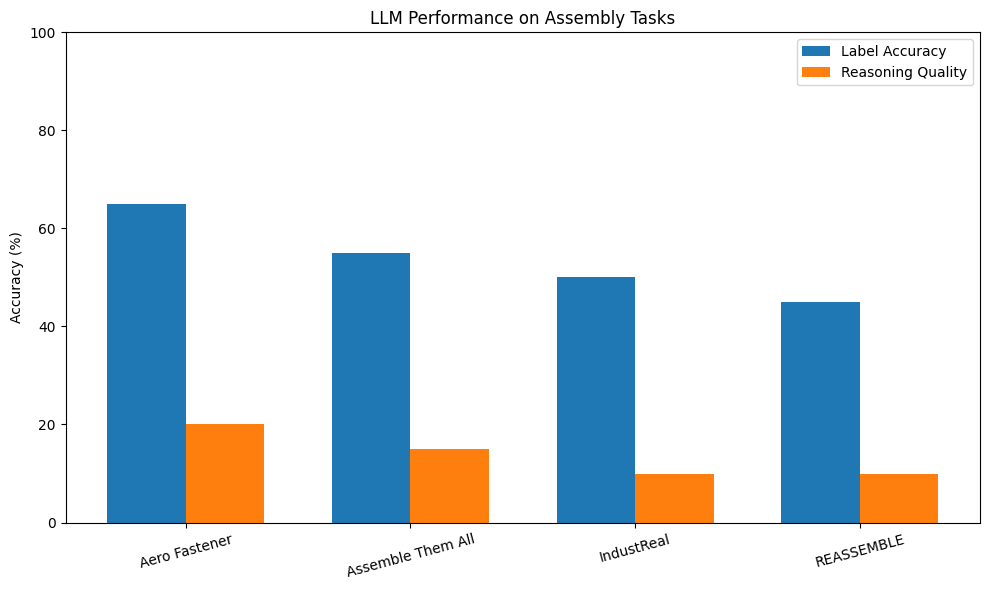

In [2]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['Aero Fastener', 'Assemble Them All', 'IndustReal', 'REASSEMBLE']
label_acc = [65, 55, 50, 45]        # approximate values - update with your real numbers
reasoning_acc = [20, 15, 10, 10]    # very low reasoning quality

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, label_acc, width, label='Label Accuracy')
ax.bar(x + width/2, reasoning_acc, width, label='Reasoning Quality')

ax.set_ylabel('Accuracy (%)')
ax.set_title('LLM Performance on Assembly Tasks')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=15)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()